# Anatomy of a "Perfect" Classifier — Disease Prediction & Data Leakage

This project began as second-year coursework: predict a binary `diagnosis` (1 = disease, ~5% of cases) from 10 anonymized patient features, and it reported a spectacular **validation ROC-AUC of 0.997**.

Revisiting it with a correct evaluation protocol tells a different story:

1. **The original pipeline leaked data** — it oversampled (ADASYN) *before* splitting off the validation set, so synthetic near-copies of validation patients were present in training. It also fit its feature transformer on the test set.
2. **With leakage removed, every model scores at chance** (ROC-AUC ≈ 0.5). The features carry no signal at all — near-zero mutual information with the target.
3. **The same flawed protocol still "achieves" ROC-AUC ≈ 0.99 on this noise**, reproduced below. The perfect score was manufactured entirely by the evaluation bug.
4. **The rebuilt pipeline is sound**: applied to a real diagnostic dataset (Wisconsin breast cancer) it reaches honest, leakage-free ROC-AUC ≈ 0.99 — and its test suite proves it recovers planted signal.

The reusable pipeline lives in `src/disease_prediction/`; model selection runs once via `python -m disease_prediction.train` and this notebook reads its report from `models/metrics.json`.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))

from disease_prediction import config
from disease_prediction.data import load_train
from disease_prediction.evaluate import evaluate_probabilities
from disease_prediction.pipeline import build_candidates

# Plot style: recessive grid, fixed CVD-safe palette.
BLUE, AQUA, YELLOW, RED = "#2a78d6", "#1baf7a", "#eda100", "#e34948"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e2", "axes.axisbelow": True,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 12,
    "legend.frameon": False, "font.size": 10,
})
FIGDIR = config.FIGURES_DIR
FIGDIR.mkdir(parents=True, exist_ok=True)
SEED = config.RANDOM_SEED

## 1. The data: 4,000 patients, 19 negatives per positive

4,000 patients, 10 features, no missing values


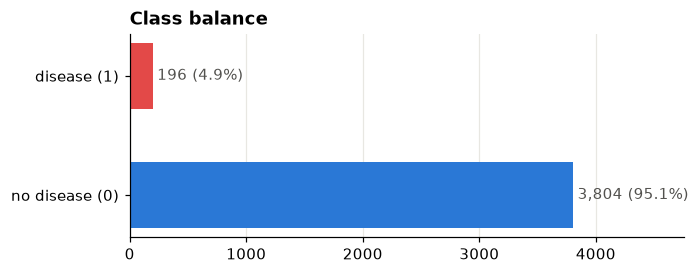

In [2]:
X, y = load_train(config.TRAIN_PATH)
print(f"{len(X):,} patients, {X.shape[1]} features, no missing values")

counts = y.value_counts()
fig, ax = plt.subplots(figsize=(6.5, 2.4))
bars = ax.barh(["no disease (0)", "disease (1)"], counts.values, color=[BLUE, RED], height=0.55)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_width() + 40, bar.get_y() + bar.get_height() / 2,
            f"{v:,} ({v/len(y):.1%})", va="center", fontsize=10, color="#52514e")
ax.set_xlim(0, counts.max() * 1.25)
ax.set_title("Class balance")
ax.grid(axis="y", visible=False)
fig.savefig(FIGDIR / "class_balance.png", bbox_inches="tight", dpi=150)
plt.show()

At 5% prevalence, a model that always says "healthy" is 95% accurate and clinically useless — so everything below is measured with ROC-AUC / PR-AUC and thresholded precision/recall, never accuracy.

## 2. First red flag: the features look like noise

Every feature is uniform on [0, 1], and — crucially — the distributions are indistinguishable between the two classes.

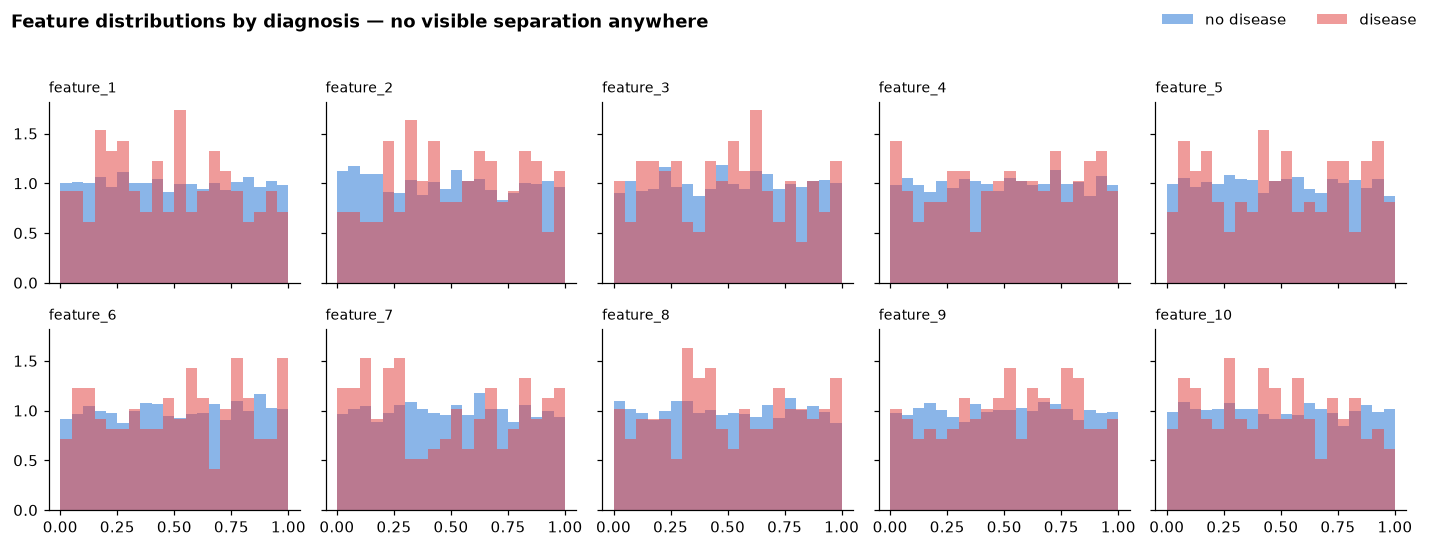

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5), sharex=True, sharey=True)
bins = np.linspace(0, 1, 21)
for ax, col in zip(axes.ravel(), config.FEATURES):
    ax.hist(X.loc[y == 0, col], bins=bins, density=True, color=BLUE, alpha=0.55, label="no disease")
    ax.hist(X.loc[y == 1, col], bins=bins, density=True, color=RED, alpha=0.55, label="disease")
    ax.set_title(col, fontsize=9, fontweight="normal")
    ax.grid(visible=False)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncols=2)
fig.suptitle("Feature distributions by diagnosis — no visible separation anywhere",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIGDIR / "feature_distributions.png", bbox_inches="tight", dpi=150)
plt.show()

In [4]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=SEED)
print("Mutual information with diagnosis, per feature:")
print(pd.Series(mi.round(4), index=config.FEATURES).to_string())
print(f"\nMax MI = {mi.max():.4f} — effectively zero (strong univariate signal would be > 0.01).")

Mutual information with diagnosis, per feature:
feature_1     0.0000
feature_2     0.0019
feature_3     0.0005
feature_4     0.0000
feature_5     0.0019
feature_6     0.0002
feature_7     0.0000
feature_8     0.0000
feature_9     0.0000
feature_10    0.0000

Max MI = 0.0019 — effectively zero (strong univariate signal would be > 0.01).


Univariate checks can miss interaction effects, so this alone doesn't prove there is nothing to learn — that verdict comes from the models themselves, under a protocol that cannot cheat.

## 3. The experiment: flawed protocol vs. correct protocol, same data

**Flawed (the original coursework):** oversample the whole dataset with ADASYN, *then* split into train/validation. Synthetic minority points are interpolations of real ones, so nearly every validation positive has close relatives in training — a nearest-neighbour memoriser looks brilliant.

**Correct:** split first; scaling and SMOTE live inside an `imblearn.Pipeline`, so they are re-fit on the training folds only. The validation split is never resampled, never seen.

In [5]:
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# --- Flawed protocol: resample BEFORE splitting (do not do this) ---
X_res, y_res = ADASYN(random_state=SEED).fit_resample(X, y)
Xtr, Xv, ytr, yv = train_test_split(X_res, y_res, test_size=0.2, random_state=SEED)
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1).fit(Xtr, ytr)
leaky_auc = roc_auc_score(yv, rf.predict_proba(Xv)[:, 1])
print(f"Flawed protocol  (ADASYN -> split): ROC-AUC = {leaky_auc:.3f}   <- looks amazing, is fake")

# --- Correct protocol results, from `python -m disease_prediction.train` ---
report = json.loads(config.METRICS_PATH.read_text())
print("\nCorrect protocol (split -> fold-safe SMOTE), validation scores:")
for name, r in report["all_candidates"].items():
    print(f"  {name:20s} cv_roc_auc={r['cv_roc_auc']:.3f}  val_roc_auc={r['val_roc_auc']:.3f}")

Flawed protocol  (ADASYN -> split): ROC-AUC = 0.990   <- looks amazing, is fake

Correct protocol (split -> fold-safe SMOTE), validation scores:
  logistic_regression  cv_roc_auc=0.514  val_roc_auc=0.440
  random_forest        cv_roc_auc=0.541  val_roc_auc=0.401
  gradient_boosting    cv_roc_auc=0.529  val_roc_auc=0.398
  xgboost              cv_roc_auc=0.513  val_roc_auc=0.419


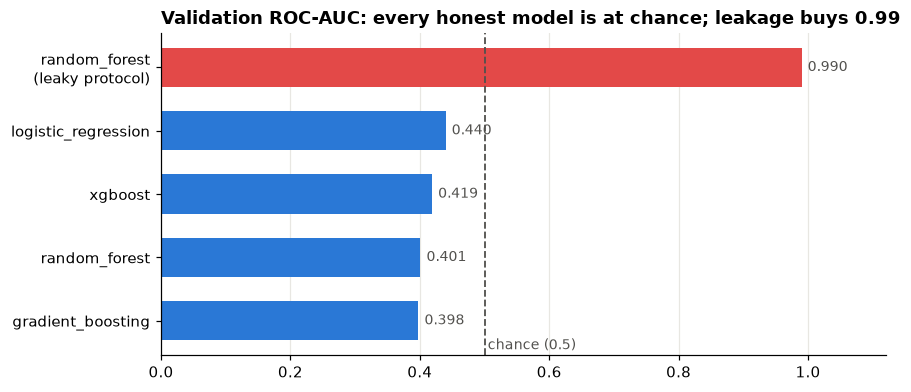

In [6]:
candidates = pd.DataFrame(report["all_candidates"]).T.sort_values("val_roc_auc")

fig, ax = plt.subplots(figsize=(8.5, 3.8))
names = list(candidates.index) + ["random_forest\n(leaky protocol)"]
vals = list(candidates["val_roc_auc"]) + [leaky_auc]
colors = [BLUE] * len(candidates) + [RED]
bars = ax.barh(names, vals, color=colors, height=0.62)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9, color="#52514e")
ax.axvline(0.5, color="#52514e", linewidth=1.2, linestyle="--")
ax.annotate("chance (0.5)", (0.505, -0.45), fontsize=9, color="#52514e")
ax.set_xlim(0, 1.12)
ax.set_title("Validation ROC-AUC: every honest model is at chance; leakage buys 0.99")
ax.grid(axis="y", visible=False)
fig.savefig(FIGDIR / "leaky_vs_honest.png", bbox_inches="tight", dpi=150)
plt.show()

Four model families, tuned with stratified 5-fold grid search, all land at ROC-AUC ≈ 0.5 when evaluated honestly — while the leaky protocol conjures 0.99 out of the *same random noise*. The anonymized course dataset simply has no learnable relationship between features and diagnosis.

> The saved `models/metrics.json` and `models/final_model.joblib` record this honest result. `python -m disease_prediction.predict` still produces test predictions, but on this dataset they are — provably — no better than predicting the base rate.

## 4. The pipeline itself is sound: real data, honest 0.99

Same code path (`build_candidates()` → stratified CV grid search → held-out validation), applied to a real diagnostic dataset: the Wisconsin breast cancer data that ships with scikit-learn (569 tumours, 30 features, `1` = malignant).

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV, StratifiedKFold

bc = load_breast_cancer(as_frame=True)
Xb = bc.data
yb = (bc.target == 0).astype(int)  # sklearn codes malignant as 0; flip so 1 = malignant

Xb_tr, Xb_val, yb_tr, yb_val = train_test_split(
    Xb, yb, test_size=0.2, stratify=yb, random_state=SEED
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
bc_results = {}
for name in ["logistic_regression", "xgboost"]:
    spec = build_candidates()[name]
    search = GridSearchCV(spec["pipeline"], spec["params"], scoring="roc_auc", cv=cv, n_jobs=-1)
    search.fit(Xb_tr, yb_tr)
    probs = search.predict_proba(Xb_val)[:, 1]
    bc_results[name] = evaluate_probabilities(yb_val, probs)
    print(f"{name:20s} val_roc_auc={bc_results[name]['roc_auc']:.3f} "
          f"val_pr_auc={bc_results[name]['pr_auc']:.3f}")

logistic_regression  val_roc_auc=0.995 val_pr_auc=0.993


xgboost              val_roc_auc=0.993 val_pr_auc=0.992


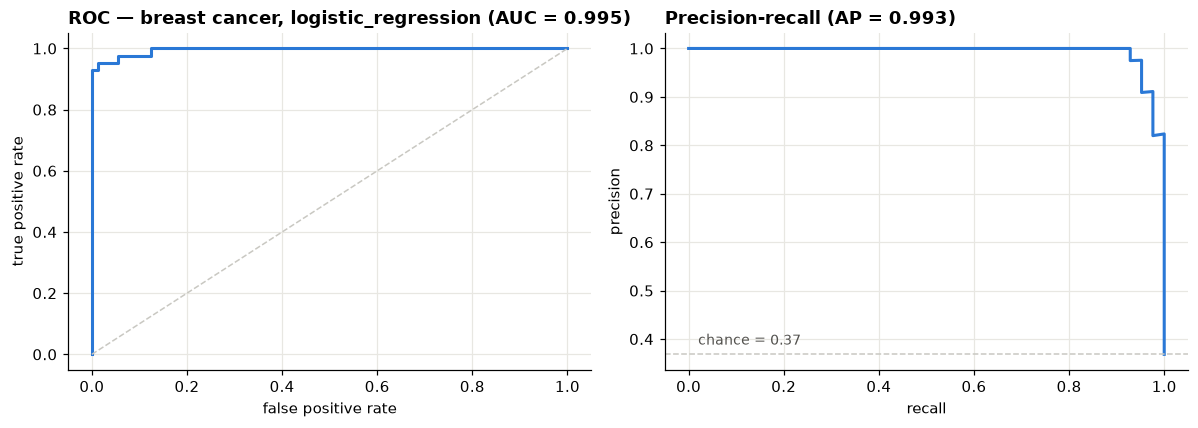

{
  "roc_auc": 0.9953703703703703,
  "pr_auc": 0.9931011971184138,
  "threshold": 0.5,
  "precision": 0.975609756097561,
  "recall": 0.9523809523809523,
  "f1": 0.963855421686747,
  "confusion_matrix": {
    "tn": 71,
    "fp": 1,
    "fn": 2,
    "tp": 40
  }
}


In [8]:
from sklearn.metrics import precision_recall_curve, roc_curve

best_bc = max(bc_results, key=lambda n: bc_results[n]["roc_auc"])
spec = build_candidates()[best_bc]
search = GridSearchCV(spec["pipeline"], spec["params"], scoring="roc_auc",
                      cv=cv, n_jobs=-1).fit(Xb_tr, yb_tr)
probs = search.predict_proba(Xb_val)[:, 1]

fpr, tpr, _ = roc_curve(yb_val, probs)
prec, rec, _ = precision_recall_curve(yb_val, probs)
m = bc_results[best_bc]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, color=BLUE, linewidth=2)
axes[0].plot([0, 1], [0, 1], color="#c9c8c2", linewidth=1, linestyle="--")
axes[0].set_title(f"ROC — breast cancer, {best_bc} (AUC = {m['roc_auc']:.3f})")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")

axes[1].plot(rec, prec, color=BLUE, linewidth=2)
axes[1].axhline(yb_val.mean(), color="#c9c8c2", linewidth=1, linestyle="--")
axes[1].annotate(f"chance = {yb_val.mean():.2f}", (0.02, yb_val.mean() + 0.02),
                 fontsize=9, color="#52514e")
axes[1].set_title(f"Precision-recall (AP = {m['pr_auc']:.3f})")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
fig.tight_layout()
fig.savefig(FIGDIR / "breast_cancer_roc_pr.png", bbox_inches="tight", dpi=150)
plt.show()

print(json.dumps(m, indent=2))

When there *is* signal, the identical pipeline finds it and reports it honestly — high AUC with zero leakage. The unit tests in `tests/test_pipeline.py` make the same point mechanically: every candidate pipeline must recover a planted signal under cross-validation.

## 5. Takeaways

1. **Resample after you split, never before.** Oversamplers like SMOTE/ADASYN interpolate between minority points; applied before the split they plant near-copies of validation cases inside the training set. Fold-safe placement inside an `imblearn.Pipeline` makes the mistake structurally impossible.
2. **A too-good number is a bug report.** ROC-AUC 0.997 on 10 anonymous features should trigger an audit, not a celebration. The honest score on this dataset is ≈ 0.5 — the features are noise.
3. **Never `fit_transform` on test data.** The original also fit its polynomial feature transformer on the test set — a second, independent leak.
4. **Accuracy is meaningless at 5% prevalence.** Use ROC-AUC / PR-AUC for ranking quality and report precision/recall at an explicitly tuned threshold.
5. **Negative results are results.** Proving a dataset unlearnable — and explaining exactly how the "perfect" score was fabricated — is more valuable than the fabricated score ever was.